- Blending Images is done by using the cv2.addWeighted() function. that uses both images and combines them 
- To blend images we use simple formula:

$$
\text{new\_pixel} = \alpha \cdot \text{pixel}_1 + \beta \cdot \text{pixel}_2 + \gamma
$$

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
Img1 = cv2.imread('../doginbagpack.jpg')
Img1 = cv2.cvtColor(Img1, cv2.COLOR_BGR2RGB)
Img2 = cv2.imread('../donotcopy.png')
Img2 = cv2.cvtColor(Img2, cv2.COLOR_BGR2RGB)

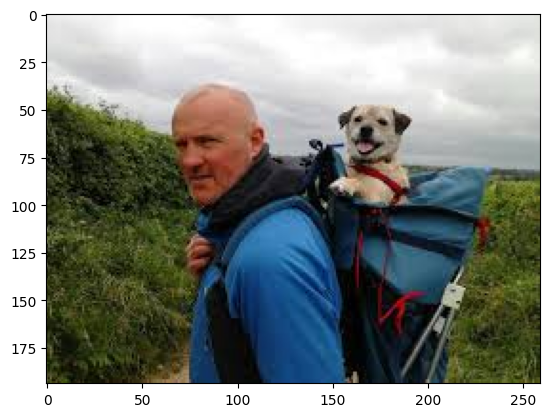

In [3]:
plt.imshow(Img1)

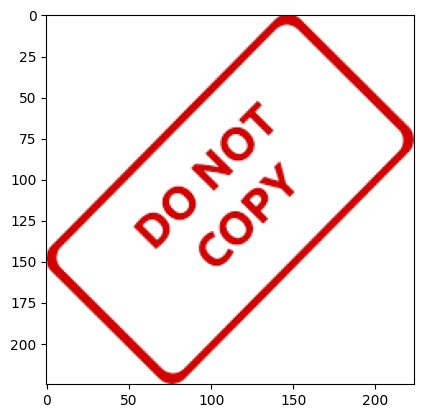

In [4]:
plt.imshow(Img2)

In [5]:
Img1.shape

(194, 259, 3)

In [6]:
Img2.shape

(225, 224, 3)

# Blending images of the same sizes 

In [7]:
Img1 = cv2.resize(Img1, (1200, 1200))
Img2 = cv2.resize(Img2, (1200, 1200))

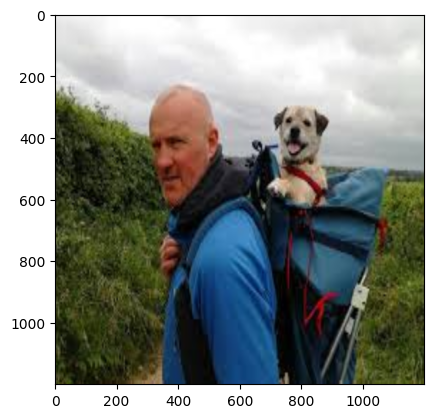

In [8]:
plt.imshow(Img1)

In [9]:
blended = cv2.addWeighted(src1=Img1, alpha=0.8, src2=Img2, beta=0.1, gamma=10) # if want src1 to be more dominant, then alpha should be more than beta
# AddWeight in only work on images of the same size 

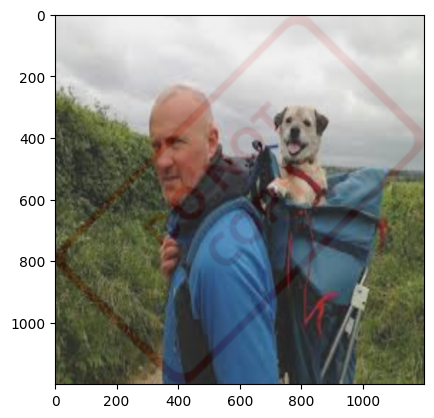

In [10]:
plt.imshow(blended)

In [11]:
# Overlay small image on top of a larger image (No blending)
# Numpy reassignment

In [12]:
Img1 = cv2.imread('../doginbagpack.jpg')
Img1 = cv2.cvtColor(Img1, cv2.COLOR_BGR2RGB)
Img2 = cv2.imread('../donotcopy.png')
Img2 = cv2.cvtColor(Img2, cv2.COLOR_BGR2RGB)

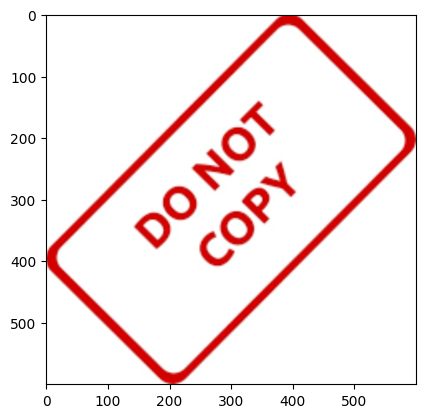

In [13]:
Img2 = cv2.resize(Img2, (600, 600))
plt.imshow(Img2)

In [14]:
Img1.shape

(194, 259, 3)

In [15]:
Img2.shape

(600, 600, 3)

In [16]:
Img1 = cv2.resize(Img1, (1200, 1200))

# blend together images of different sizes 

In [17]:
large_img = Img1
small_img = Img2 

In [18]:
x_offset = 0 
y_offset = 0

In [19]:
x_end = x_offset + small_img.shape[1] 
y_end = y_offset + small_img.shape[0] 

In [20]:
small_img.shape

(600, 600, 3)

In [21]:
large_img.shape

(1200, 1200, 3)

In [22]:
large_img[y_offset: y_end, x_offset: x_end] = small_img 

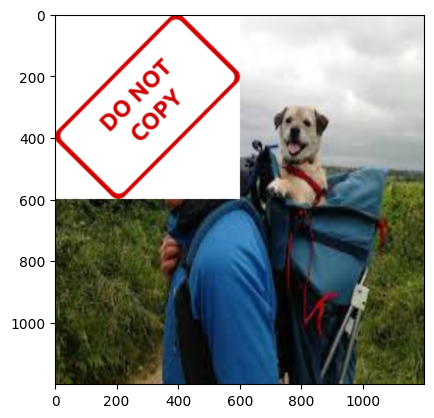

In [23]:
plt.imshow(large_img)

# What if we want to mask part of the smaller image ? 

In [24]:
Img1 = cv2.imread('../doginbagpack.jpg')
Img1 = cv2.cvtColor(Img1, cv2.COLOR_BGR2RGB)
Img2 = cv2.imread('../donotcopy.png')
Img2 = cv2.cvtColor(Img2, cv2.COLOR_BGR2RGB)

In [25]:
Img2 = cv2.resize(Img2, (600, 600))

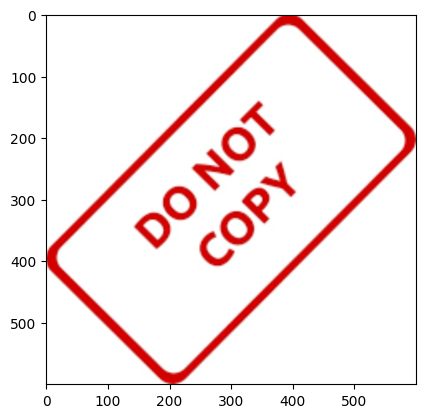

In [26]:
plt.imshow(Img2)

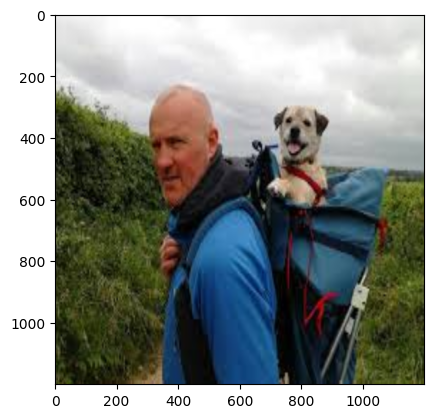

In [27]:
Img1 = cv2.resize(Img1, (1200, 1200))
plt.imshow(Img1)

In [28]:
x_offset = 1200 - 600
y_offset = 1200 - 600

In [29]:
rows, cols, channels = Img2.shape

In [30]:
rows

600

In [31]:
cols

600

In [32]:
# ROI (Region of Interest)
roi = Img1[y_offset: 1200, x_offset: 1200]

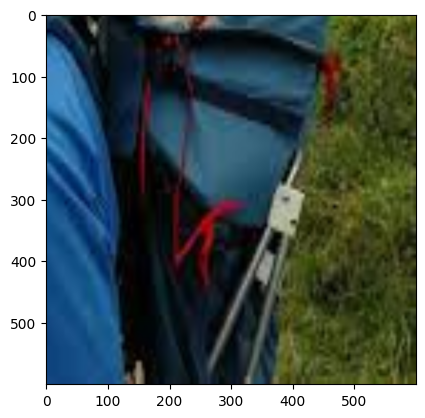

In [33]:
plt.imshow(roi)

In [34]:
Img2gray = cv2.cvtColor(Img2, cv2.COLOR_BGR2GRAY)

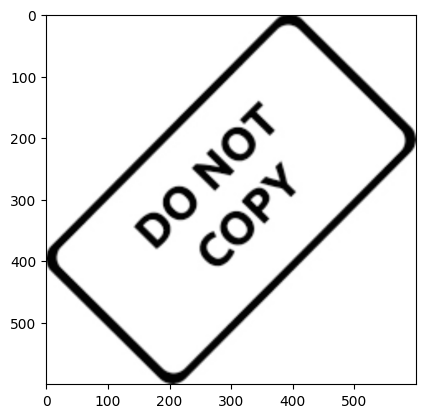

In [35]:
plt.imshow(Img2gray, cmap='gray')

In [36]:
mask_inv = cv2.bitwise_not(Img2gray)

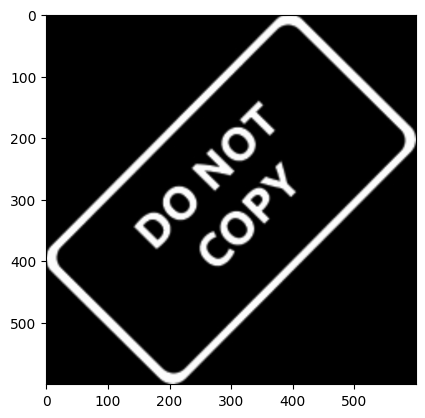

In [37]:
plt.imshow(mask_inv, cmap='gray')

In [38]:
mask_inv.shape

(600, 600)

In [39]:
white_background = np.full(Img2.shape, 255, dtype = np.uint8) 

In [40]:
bk = cv2.bitwise_or(white_background, white_background, mask=mask_inv)

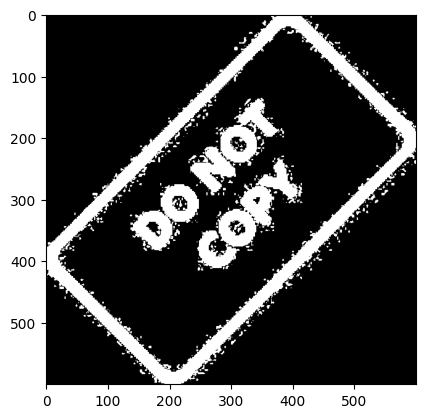

In [41]:
plt.imshow(bk)

In [42]:
fg = cv2.bitwise_or(Img2, Img2, mask=mask_inv)

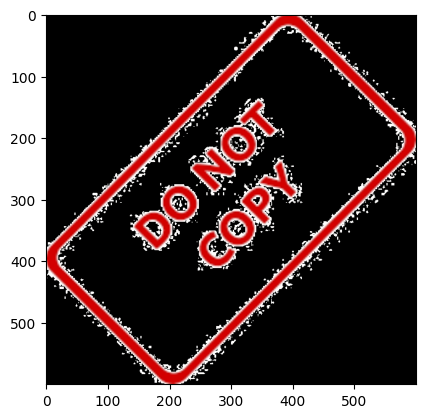

In [43]:
plt.imshow(fg)

In [44]:
final_roi = cv2.bitwise_or(roi, fg)

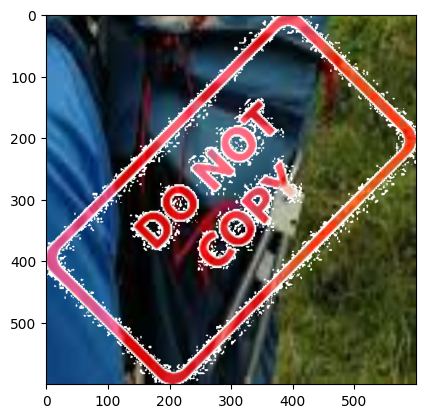

In [45]:
plt.imshow(final_roi)

In [46]:
large_img = Img1
small_img = final_roi

In [47]:
large_img[y_offset: y_offset + small_img.shape[0], x_offset: x_offset + small_img.shape[1]] = small_img

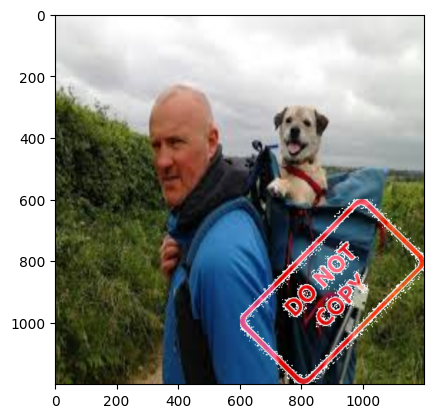

In [48]:
plt.imshow(large_img)